In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FuncAnimation, PillowWriter

In [81]:
from matplotlib.colors import ListedColormap
import numpy as np

COLORS_HEX = ['#D09B2C', '#D19C2E', '#D19C30', '#D29D32', '#D29E34', '#D39F36', '#D39F38', '#D4A03A', '#D4A13B', '#D5A23D', '#D5A23F', '#D6A341', '#D7A443', '#D7A544', '#D8A546', '#D8A648', '#D9A749', '#D9A84B', '#DAA84D', '#DAA94F', '#DBAA50', '#DBAB52', '#DCAB54', '#DCAC55', '#DDAD57', '#DDAE58', '#DEAE5A', '#DEAF5C', '#DFB05D', '#DFB15F', '#E0B161', '#E0B262', '#E1B364', '#E1B465', '#E1B467', '#E2B569', '#E2B66A', '#E3B76C', '#E3B76D', '#E4B86F', '#E4B971', '#E5BA72', '#E5BB74', '#E6BB75', '#E6BC77', '#E6BD79', '#E7BE7A', '#E7BE7C', '#E8BF7D', '#E8C07F', '#E9C181', '#E9C182', '#E9C284', '#EAC385', '#EAC487', '#EBC589', '#EBC58A', '#EBC68C', '#ECC78D', '#ECC88F', '#EDC891', '#EDC992', '#EDCA94', '#EECB95', '#EECC97', '#EECC98', '#EFCD9A', '#EFCE9C', '#F0CF9D', '#F0CF9F', '#F0D0A0', '#F1D1A2', '#F1D2A4', '#F1D3A5', '#F2D3A7', '#F2D4A8', '#F2D5AA', '#F3D6AC', '#F3D7AD', '#F3D7AF', '#F4D8B0', '#F4D9B2', '#F4DAB4', '#F5DBB5', '#F5DBB7', '#F5DCB9', '#F6DDBA', '#F6DEBC', '#F6DFBD', '#F6DFBF', '#F7E0C1', '#F7E1C2', '#F7E2C4', '#F8E3C5', '#F8E3C7', '#F8E4C9', '#F8E5CA', '#F9E6CC', '#F9E7CE', '#F9E7CF', '#F9E8D1', '#FAE9D2', '#FAEAD4', '#FAEBD6', '#FAEBD7', '#FBECD9', '#FBEDDB', '#FBEEDC', '#FBEFDE', '#FCEFE0', '#FCF0E1', '#FCF1E3', '#FCF2E4', '#FCF3E6', '#FDF4E8', '#FDF4E9', '#FDF5EB', '#FDF6ED', '#FDF7EE', '#FEF8F0', '#FEF8F2', '#FEF9F3', '#FEFAF5', '#FEFBF7', '#FEFCF8', '#FFFDFA', '#FFFDFC', '#FFFEFD', '#FFFFFF', '#FDFEFE', '#FCFCFD', '#FAFBFC', '#F8FAFB', '#F6F9FA', '#F5F7F9', '#F3F6F8', '#F1F5F7', '#EFF4F6', '#EEF2F5', '#ECF1F5', '#EAF0F4', '#E9EFF3', '#E7EDF2', '#E5ECF1', '#E3EBF0', '#E2E9EF', '#E0E8EE', '#DEE7ED', '#DDE6EC', '#DBE4EB', '#D9E3EA', '#D8E2E9', '#D6E1E8', '#D4DFE7', '#D2DEE6', '#D1DDE5', '#CFDCE5', '#CDDBE4', '#CCD9E3', '#CAD8E2', '#C8D7E1', '#C6D6E0', '#C5D4DF', '#C3D3DE', '#C1D2DD', '#C0D1DC', '#BECFDB', '#BCCEDA', '#BBCDD9', '#B9CCD8', '#B7CBD7', '#B5C9D7', '#B4C8D6', '#B2C7D5', '#B0C6D4', '#AFC4D3', '#ADC3D2', '#ABC2D1', '#AAC1D0', '#A8C0CF', '#A6BECE', '#A4BDCD', '#A3BCCC', '#A1BBCB', '#9FBACB', '#9EB8CA', '#9CB7C9', '#9AB6C8', '#99B5C7', '#97B4C6', '#95B2C5', '#93B1C4', '#92B0C3', '#90AFC2', '#8EAEC1', '#8DACC0', '#8BABC0', '#89AABF', '#87A9BE', '#86A8BD', '#84A6BC', '#82A5BB', '#81A4BA', '#7FA3B9', '#7DA2B8', '#7BA1B7', '#7A9FB6', '#789EB6', '#769DB5', '#749CB4', '#739BB3', '#719AB2', '#6F98B1', '#6D97B0', '#6C96AF', '#6A95AE', '#6894AD', '#6693AD', '#6492AC', '#6390AB', '#618FAA', '#5F8EA9', '#5D8DA8', '#5B8CA7', '#598BA6', '#5889A5', '#5688A4', '#5487A4', '#5286A3', '#5085A2', '#4E84A1', '#4C83A0', '#4A829F', '#48809E', '#467F9D', '#447E9C', '#427D9C', '#407C9B', '#3E7B9A', '#3C7A99', '#397998', '#377797', '#357696', '#327595', '#307495', '#2D7394', '#2B7293', '#287192', '#257091', '#226F90', '#1F6E8F', '#1B6C8E', '#176B8D', '#136A8D', '#0E698C', '#07688B']

def get_cmap(center='#002060'):
    def hex_to_rgb(h):
        h = h.lstrip('#')
        return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)]) / 255.

    colors = np.array([hex_to_rgb(h) for h in COLORS_HEX])
    center_rgb = hex_to_rgb(center)

    n = len(colors)
    mid = n // 2

    # Originale Endfarben beibehalten
    gold = colors[0]
    blue = colors[-1]

    # Gold -> neue Zentralfarbe -> Blau
    left  = np.linspace(gold, center_rgb, mid + 1)
    right = np.linspace(center_rgb, blue, n - mid)

    new_colors = np.vstack([left[:-1], right])

    return ListedColormap(new_colors, name='gold_darkblue_blue')

In [2]:
import sys
sys.path.append('/home/r/Robert.Reichert/artsy-colors')
from gold_white_blue_matplotlib import get_cmap

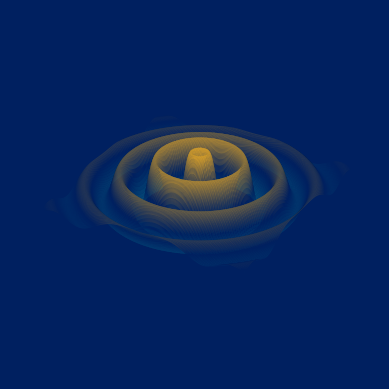

In [82]:
x = np.linspace(-5,5,200)
y = np.linspace(-5,5,200)

XX, YY = np.meshgrid(x,y)

royal=get_cmap().reversed()

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor('#002060')
ax.set_facecolor('#002060')

Z=np.exp(-(XX**2+YY**2)/2/3**2)*np.sin(4*np.sqrt(XX**2+YY**2))
surf=[ax.plot_surface(XX,YY,Z,cmap=royal,edgecolor='none',rstride=1,cstride=1)]
ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
ax.set_zlim([-2,2]); ax.axis('off')
plt.show()

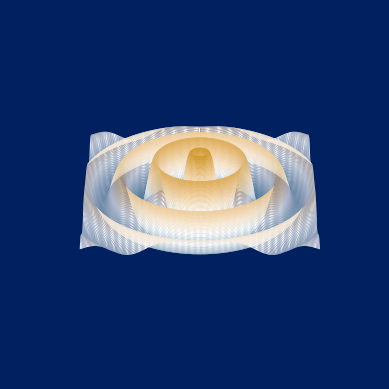

In [42]:
x = np.linspace(-5,5,200)
y = np.linspace(-5,5,200)

XX, YY = np.meshgrid(x,y)

royal=get_cmap().reversed()

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor('#002060')
ax.set_facecolor('#002060')

Z=np.exp(-(XX**2+YY**2)/2/3**2)*np.sin(4*np.sqrt(XX**2+YY**2))
surf=[ax.plot_surface(XX,YY,Z,cmap=royal,edgecolor='none',rstride=1,cstride=1)]
ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
ax.set_zlim([-2,2]); ax.axis('off')

def animate(frame):
    ax.cla()
    Z=np.exp(-(XX**2+YY**2)/2/3**2)*np.sin(4*np.sqrt(XX**2+YY**2)-8*np.deg2rad(frame))
    ax.plot_surface(XX,YY,Z,cmap=royal,edgecolor='none',rstride=1,cstride=1)
    ax.set_facecolor('#002060')
    ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
    ax.set_zlim([-2,2])
    ax.axis('off')
    ax.view_init(elev=30,azim=frame)

ani=FuncAnimation(fig, animate, frames=360, interval=50)

ani.save("./animations/wave_animation_v4.gif",
    writer=PillowWriter(fps=20),
    dpi=100)

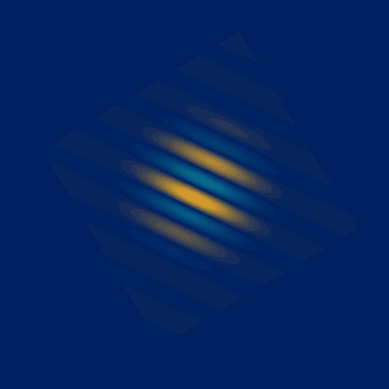

In [85]:
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)

XX, YY = np.meshgrid(x,y)

royal=get_cmap().reversed()

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor('#002060')
ax.set_facecolor('#002060')

Z=2*np.exp(-(XX**2+YY**2)/2/1.5**2)*np.sin(3*XX+2*YY)

surf=[ax.contourf(XX,YY,Z,levels=np.linspace(-1.67,1.67,31),cmap=royal,extend='both')]
ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
ax.set_zlim([-2,2]); ax.axis('off')
ax.view_init(elev=90,azim=60)
plt.show()

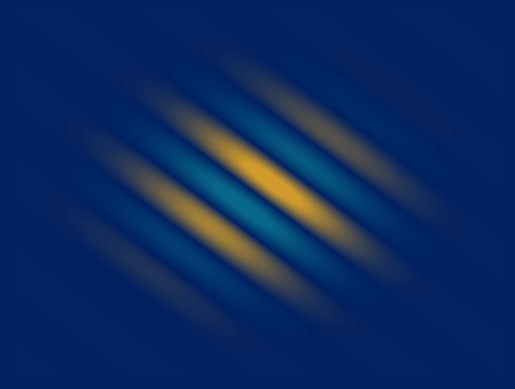

In [91]:
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)

XX, YY = np.meshgrid(x,y)

royal=get_cmap().reversed()

fig=plt.figure()
ax=fig.add_subplot(111)
fig.patch.set_facecolor('#002060')
ax.set_facecolor('#002060')

Z=2*np.exp(-(XX**2+YY**2)/2/2**2)*np.sin(4*XX+2*YY)
ax.contourf(XX,YY,Z,cmap=royal,levels=np.linspace(-1.7,1.7,99),extend='both')
ax.set_xlim([-5,5])
ax.set_ylim([-5,5])
ax.axis('off')

def animate(frame):
    ax.cla()
    Z=2*np.exp(-(XX**2+YY**2)/2/1.5**2)*np.sin(2.5*XX+2.5*YY-6*np.deg2rad(frame))
    ax.contourf(XX,YY,Z,cmap=royal,levels=np.linspace(-1.7,1.7,99),extend='both')
    ax.set_facecolor('#002060')
    ax.set_xlim([-5,5])
    ax.set_ylim([-5,5])
    ax.axis('off')

ani=FuncAnimation(fig, animate, frames=60, interval=50)

from matplotlib.animation import FFMpegWriter

ani.save(
    "./animations/wavelet2d_animation_v8.mp4",
    writer=FFMpegWriter(fps=20),
    dpi=100
)

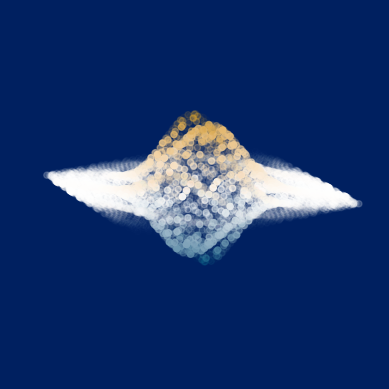

In [49]:
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)

XX, YY = np.meshgrid(x,y)

royal=get_cmap().reversed()

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor('#002060')
ax.set_facecolor('#002060')

Z=2*np.exp(-(XX**2+YY**2)/2/2**2)*np.sin(4*XX+2*YY)
opacity=np.abs(Z)
opacity/=np.max(opacity)
surf=[ax.scatter(XX,YY,Z,c=Z,cmap=royal,alpha=opacity)]
ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
ax.set_zlim([-2,2]); ax.axis('off')

def animate(frame):
    ax.cla()
    Z=2*np.exp(-(XX**2+YY**2)/2/1.5**2)*np.sin(3*XX+2*YY-6*np.deg2rad(frame))
    opacity=np.abs(Z)
    opacity/=np.max(opacity)
    ax.scatter(XX,YY,Z,c=Z,cmap=royal,alpha=opacity)
    ax.set_facecolor('#002060')
    ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
    ax.set_zlim([-2,2])
    ax.axis('off')
    ax.view_init(elev=20,azim=60+frame/4)

ani=FuncAnimation(fig, animate, frames=360, interval=50)

ani.save("./animations/wavelet2d_animation_v5.gif",
    writer=PillowWriter(fps=20),
    dpi=100)

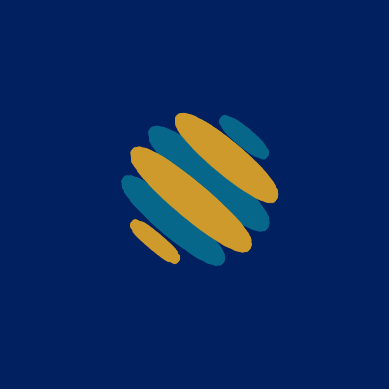

In [120]:
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)
z = np.linspace(-5,5,100)

XX, YY, ZZ = np.meshgrid(x,y,z)

royal=get_cmap().reversed()

fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
fig.patch.set_facecolor('#002060')
ax.set_facecolor('#002060')

Z=2*np.exp(-(XX**2+YY**2+ZZ**2)/2/2**2)*np.sin(2.5*XX)
mask = Z>0.5
ax.scatter(XX[mask],YY[mask],ZZ[mask],c='#D09B2C')
mask = Z<-0.5
ax.scatter(XX[mask],YY[mask],ZZ[mask],c='#07688B')
ax.set_xlim([-5,5]); ax.set_ylim([-5,5])
ax.set_zlim([-5,5]); ax.axis('off')
ax.view_init(elev=80,azim=40)
plt.show()

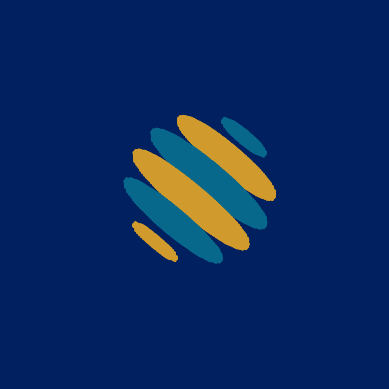

In [121]:
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)
z = np.linspace(-5,5,100)

XX, YY, ZZ = np.meshgrid(x, y, z, indexing="ij")

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
fig.patch.set_facecolor("#002060")
ax.set_facecolor("#002060")

F = 2*np.exp(-(XX**2+YY**2+ZZ**2)/(2*2**2))*np.sin(2.5*XX)

mask = np.abs(F) > 0.5
xp, yp, zp = XX[mask], YY[mask], ZZ[mask]
colors = np.where(F[mask] > 0, "#D09B2C", "#07688B")

ax.scatter(xp, yp, zp, c=colors, s=2, depthshade=False)

ax.set_xlim([-5,5]); ax.set_ylim([-5,5]); ax.set_zlim([-5,5])
ax.axis("off")
ax.view_init(elev=80, azim=40)
plt.show()

In [122]:
import numpy as np
import pyvista as pv

x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)
z = np.linspace(-5,5,100)

XX, YY, ZZ = np.meshgrid(x, y, z, indexing="ij")

F = 2*np.exp(-(XX**2+YY**2+ZZ**2)/(2*2**2))*np.sin(2.5*XX)

grid = pv.StructuredGrid(XX, YY, ZZ)
grid["F"] = F.ravel(order="F")

pos = grid.contour([0.5], scalars="F")
neg = grid.contour([-0.5], scalars="F")

p = pv.Plotter()
p.set_background("#002060")
p.add_mesh(pos, color="#D09B2C", opacity=1.0, smooth_shading=True)
p.add_mesh(neg, color="#07688B", opacity=1.0, smooth_shading=True)

p.camera_position = [(10, -12, 8), (0, 0, 0), (0, 0, 1)]
p.show()

ModuleNotFoundError: No module named 'pyvista'